2026 April 6

Lambert Zhang

Self-assembled documentation for Kendall Butler's "JCN-Traveling-Wave-Pathways" Github repository.

https://github.com/LbZ7777777/JCN-Traveling-Wave-Pathways


# Section 1 "setup.py"

## setup.py "class izzy"

In [1]:
from brian2 import *
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from math import cos, tan, sin, exp, floor, sqrt

These are code libraries the class relies upon. Most are standard libraries, but "brian2" refers to https://brian2.readthedocs.io/en/stable/index.html

In [4]:
izzy_eqns = '''
dv/dt = (0.04*v**2 + 5*v + 140 - u + I)/ms : 1
du/dt = (a*(b*v - u))/ms : 1
dI/dt = (0 - I)/tau : 1
a : 1
b : 1
c : 1
d : 1
x : 1
y : 1
z : 1
ecn : 1
'''

izzy_res = 'v = c ; u = u + d'

izzy_thresh = 'v>30'

The first and the second equations $dv/dt$ and $du/dt$ are standard Izhikevich model equations and values. (Izhikevich 2003 Section II The Model)

${a, b, c, d}$ are the 4 standard Izhikevich neuron parameters. $c, d$ are reset values/differences for $v, t$ while $a, b$ are the decay rate of $u$ and the degree to which $u$ is affected by $v$ respectively.

Butler seems to have a more advanced model for the current than Izhikevich, who simply had current injection all occur over a single timestep with a fixed amount proportional to synaptic weights plus a random "thalamic input". In contrast, Butler has current flowing into a neuron decay exponentially over timesteps.

The remaining four neuron variables are ${x, y, z, n}$. The first three of these are the neuron's cartesian coordinates in space while the last one indicates whether the neuron is an $ecn = 1$ excitory or an $ecn = 0$ inhibitory neuron.

P.S. "Izzy" prefix was appended to these variables to avoid confusion with later "eqns" variables for other classes. This is naturally only necessary because I have neglected to wrap the documentation's code blocks in to classes, in part because I do not know how to let a single class definition extend over multiple code blocks, or if that is even possible.

In [ ]:
def ecn_inhib_init(N, Percent_ecn):
        excitatory = []
        inhibitory = []
        
        for ii in range (0,N):
            if rand()>Percent_ecn:
                inhibitory.append(ii)
            else:
                excitatory.append(ii)
                
        return excitatory, inhibitory

This is clearly an attempt to randomly assign to neurons their classification as excitory or inhibitory neurons.

Note that "ii" is a single variable and that this is a single for loop, not a double loop.

In [6]:
a_inhib = '0.02 + 0.08 * rand()'
b_inhib = '0.25 - 0.05 * rand()'
c_inhib = '(-65)'
d_inhib = '2.0'
a_ecn = '0.02'
b_ecn = '0.2'
c_ecn = '(-65 + 15 * rand()**2)'
d_ecn = '8 - 6 * rand()**2'

These neuron parameters are standard values provided in the 2003 Izhikevich paper, section IV Pulse-Coupled Implementation.

In [7]:
rest = '((b-5) - sqrt((5-b)**2 - 4*0.04*140))/0.08'
restu = 'v * b'

These are resting potential calculations for $v, u$. The later is taken directly from the simpler $du/dt$ differential equation's structure, while the former clearly involves the quadratic formula. It appears to take the part of $dv/dt$ aside from $I$ and substitute $restu = 'v * b'$ in for the $u$ variable before solving the resulting quadratic equation.

In [8]:
###lower stimulation currents for inhibitory neurons
#regular random stimulation w/random magnitude
stim_type = 'I_post += rand()*STIMRANGE*(ecn_post + (2/5)*(1-ecn_post))'
#time-specific stimulation
stim_type3 = 'I_post += ((t/ms)%(1000) < 30 and (t/ms)%(1000) > 0) * SpecStim*(ecn_post + (2/5)*(1-ecn_post))'

#2 alternating sites
stim_alt21 = 'I_post += ((t/ms)%(2000) < 30 and (t/ms)%(2000) > 0) * SpecStim*(ecn_post + (2/5)*(1-ecn_post))'
stim_alt22 = 'I_post += ((t/ms + 1000)%(2000) < 30 and (t/ms + 1000)%(2000) > 0) * SpecStim*(ecn_post + (2/5)*(1-ecn_post))'

The variables $STIMRANGE$ and $SpecStim$ are defined in the simulation setup files "Wave_1.py" and etc. Clearly, the Brian2 library is capable of using variables not explicitly fed into objects from the library.

These four equation strings are used as "on_pre=" arguments for Brian's Synapse connections between Poisson porcess objects and neurons.

$stim\_type$ is a random background stimulation.

$stim\_type3$ is used with the central simulation. The full argument before the $SpecStim$ reference is a bool dictating that central stimulation occurs every $1000 ms$ for $29 ms$.

Likewise, the arguments before the $SpecStim$ term in $stim\_alt21$ and $stim\_alt22$ for the alternating simulation provide $29 ms$ bursts every $2000 ms$ with $stim\_alt22$ being $1000 ms$ delayed from $stim\_alt21$.

The actually linking of these bursting times to specific neurons such as a central block or an edge is performed with dedicated string arguments when calling "Synapse.connect".

Note that $stim\_type$ uses $rand()*STIMRANGE$ instead of $SpecStim$, but both act as the stimulation amplitude.

$ecn\_post$ refers to the value of a neuron's $ecn$ variable--generally $var-name\_pre$ and $var-name\_post$ serve such purposes with Brian. In this case, we have $ecn\_post$ which means we're looking at the class of neuron which the neuron receiving the stimulation is. Using $ecn\_pre$ in this context would make no sense since the input is a poisson group.

Again, $ecn$ is just a bool for whether a neuron is excitory or inhibitory (this is confirmed because Wave_1.py and etc. set $ecn$ along with ${a, b, c, d}$ with a boolean value), and the $(ecn\_post + (2/5)*(1-ecn\_post))$ statement is just a method of saying inhibitory neurons only get $40\%$ of an excitory neuron's stimulation. The syntax choice resembles statements I've previously seen in probability or thermodynamics such as $<x> = \sum_{x \in {a, b}} p(x) x = a * p(a) + b * (1 - p(a))$.

In [ ]:
#distance dependent connection probability 
SE_prob = "ecn_pre*C*exp(-((x_post - x_pre)**2 + (y_post - y_pre)**2 + (z_post - z_pre)**2)/lamb**2)"
SI_prob = "(1-ecn_pre)*C*exp(-((x_post - x_pre)**2 + (y_post - y_pre)**2 + (z_post - z_pre)**2)/lamb**2)"

#distance-dependant probability if distinction between excitatory and inhibitory is not necessary
allprob = 'connprob'
gen_prob = "C*exp(-((x_post - x_pre)**2 + (y_post - y_pre)**2 + (z_post - z_pre)**2)/lamb**2)"

The $SE\_prob$, $SI\_prob$, $allprob$, and $gen\_prob$ variables are all probability arguments used in Synapse.connect statements alongside a condition that $i!=j$, or no self-connection.

The $ecn\_pre$ and $1 - ecn\_pre$ arguments in $SE\_prob$ and $SI\_prob$ act as delta statements to prevent these Synapse.connect statement from acting directly upon neurons of the other class. I.e. A Synapse.connect statement acts to connect all excitory neurons to other neurons of both types and a second Synapse.connect statement connects all inhibitory neurons to other neurons of both types.

In this case we use $ecn\_pre$ because we want the neuron sending out the signal's type to govern the connection probability. Using $ecn\_post$ here would make all neurons connect to excitory and inhibitory neurons with different rule sets based on the receiving neuron's class. So your first Synapse.connect statement in this hypothetical would connect all neurons to only excitory neurons, and the second Synapse.connect statement would connect all neurons to only inhibitory neurons. But again, here we use $ecn\_pre$.

The $allprob$ and $gen_prob$ options provide a uniform, non distant-dependent probability and a distant-dependent probability which doesn't care about the type of involved neuron.

The actual distance dependence is a Gaussian $C*e^{-\frac{d^2}{\lambda^2}}$, where $C$ is a maximum connection probability defined inthe Wave_1.py and etc. code files.

In [ ]:
#random range of initial weights
SE_w = '0.5*K*rand()' 
SI_w = '-K*rand()'

These are initial weight values. Inhibitory weights are negative and double the strenght of excitory weights. $K$ is a limit on the initial weight magnitude and is defined in the Wave_1.py and etc. files.

The actual working of the weights is located in the classes for non-plastic simulations and for spike-timing-dependent-plasticity simulations.

In [ ]:
def speed(start, SPIKES_i, SPIKES_t, G_x, G_y, G_z): #probably function to calculate a wave speed analogue
    speeds = []
    induse = 0 #induce? or is this a technical term?
    time = SPIKES_t[induse]

    Search = True
    while Search == True: #finds first spike occuring after "start" time
        induse += 1
        time = SPIKES_t[induse]
        if time >= start:
            Search = False
    
    avedist = []
    for i in range(16):
        dists = []
        current = time
        while time < current + 5: #finds distance of spiking neuron from center of system; only counts spikes near wavefront
            neuron = SPIKES_i[induse]
            xval = abs(G_x[neuron] - 49.5)
            yval = abs(G_y[neuron] - 49.5)
            zval = abs(G_z[neuron] - 1)
            dist = sqrt(xval**2 + yval**2 + zval**2)
            dists.append(dist)
            induse += 1
            time = SPIKES_t[induse]
        if i > 0: #i.e. don't count i = 0 loop result
            speeds.append((np.mean(dists) - preval)/5)
        preval = np.mean(dists)

    return(np.mean(speeds))

The "speed" function computes the speed of a traveling wave by examining progression of average spike location over an $80 ms$ interval.

$start$ is the simulation time which the function examines.

$SPIKES\_i$ and $SPIKES\_t$ are Brian's "SpikeMonitor" object's outputs. It's a pair of two arrays, with $SPIKES\_t$ containing the time of all spikes in the simulationand $SPIKES\_i$ containing the index of the neuron which spiked.

${G\_x, G\_y, G\_z}$ are objects containing the full positional information data for all neurons in a neuron group. I.e. they take arguments $G.x$ and the like.

The first while loop in the function sets the $induse$ and $time$ counters to correspond with the first spike occuring after the given $start$ time.

$avedist = []$ does not appear to be used and should probably be commented out of the code. (It is likely an artifact from a previous computation implementation.) It is not referenced in any other file from the original JCN-Traveling-Waves repository.

The for loop cycles over index $i$ fifteen times, with only the results of the last fourteen trials used due to the if statement near the end of the for loop. The first loop with $i == 0$ remains necessary because it sets the first $preval$ used in the speed computation.

Within each of the for loops, the function creates a list $dists$ for the distance from the center of the simulation area of each neuron that spiked within $5 ms$ of the first examined spike in the loop. Then, the average spike location over this $5 ms$ interval is computed. This average spike location is compared with the average spike location over the previous $5 ms$ interval to find the wave speed with $v \approx \frac{d(t) - d(t - 5 ms)}{5 ms}$. Finally, the average spike location is saved into $preval$ for the next interval's use in this speed computation.

Of note is that within the for loop, the $induse$ variable is only ever incremented and never reset. This is why the function examines successive $5 ms$ intervals of spikes rather than repeatedly examining the $5 ms$ interval after the $start$ time.

Also of note is that because this function returns a metric of the average spike location velocity, it will not properly account for the spike velocity of systems with substantial curl.

In [ ]:
def props_div(SE,K):
    top = 0
    bottom = 0
    mid = 0
    total = len(SE)
    for i in range(total):
        if (SE[i] >= (0.5 * K)):
            top += 1
        if (SE[i] <= 0.0):
            bottom += 1
        if (SE[i] > 0.0) & (SE[i] < (0.5*K)): 
            mid += 1
    top = top/total
    bottom = bottom/total
    mid = mid/total
    return([mid,top,bottom])

This function's name should stand for "proportion diverged" because (when utilized as intended) it computes the proportion of excitory neurons (only works properly with excitory neurons) whose weights are above the initialized weight range $top$, below the initialized weight range $bottom$, and still within the initialized weight range (not diverged) $mid$.

The function's first argument generally takes $Synapses.w$; i.e. the list of synaptic weights (generally it's $SE.w$ or the synaptic weights originating at an excitory neuron), while the second argument is $K$, which has previously been mentioned as the range of initial inhibitory weights and is defined in the Wave_1.py etc. files.

This function is used (with additional processing) in files such as Wave_1.py to compute the directional local order.

In [ ]:
#distance dependent signal time-delay
delay = 'DELAYMULT*sqrt((x_post - x_pre)**2 + (y_post - y_pre)**2 + (z_post - z_pre)**2) * ms'

This oddly located string variable concludes the "izzy" class members. In simulation it is used as the Synapse.delay value, and $DELAYMULT$'s value is established in the Wave_1.py and etc. files. This string establishes a time delay for a synaptic connection proportional to the distance between the neurons the synapse spans.

## setup.py "class pos_3D"

In [ ]:
x = '(i%Width) - (rand_pos/2) + rand_pos*rand()'
y = '((floor(i/Width))%Height) - (rand_pos/2) + rand_pos*rand()'
z = '(floor(i/(Height*Width))) - (rand_pos/2) + rand_pos*rand()'

These three string variables are used as command arguments for a NeuronGroup initialized with ${x, y, z}$ members in its $eqns$ argument.

${Height, Width, random\_pos}$ are initialized in the Wave_1.py etc. files. $Layers$ is also initialized in Wave_1.py etc. but not used here.

The $- (rand\_pos/2) + rand\_pos*rand()$ term on each of the ${x, y, z}$ members shifts the postion of each neuron away from a defined lattice position with a uniform distribution on $(-\frac{rand\_pos}{2}, \frac{rand\_pos}{2})$.

For $x$, $i\%Width$ lays the neurons out by index i in lines of length $Width$.

For $y$, $floor(i/Width)$ separates the lines of length $Width$ into sheets. The modulus by $Height$ cuts the sheets into height $Height$ and stacks/overlaps them.

For $z$, the overlapping sheets are raised/separated into proper stacks with $floor(i/(Height*Width))$.

So the first and second layers of a system with $Width = 4$ and $Height = 3$ would be as depicted and lie fully in the first quadrant, with neuron $0$ being approximately at the coordinate system origin.

| Layer 1 | | | |
| --- | --- | --- | --- |
| 8 | 9 | 10 | 11 |
| 4 | 5 | 6 | 7 |
| 0 | 1 | 2 | 3 |

and

| Layer 2 | | | |
| --- | --- | --- | --- |
| 20 | 21 | 22 | 23 |
| 16 | 17 | 18 | 19 |
| 12 | 13 | 14 | 15 |

In [3]:
def plot_frames_flat(start, start_time, timestep, Nx, Ny, Nz, v, colorchoice, max, name):
    sum = 0.0
    initial = int(start/0.1)
    xi = 0
    yi = 0
    step = int(timestep/0.1)
    neurons = Nx * Ny * Nz
    plt.figure(figsize=(27, 3), dpi=80)
    for jj in range (0,9):
        time = initial + step * jj
        current_time = start_time + start + jj * timestep
        VoltageArray = np.zeros((Nx,Ny))
        for ii in range (0,neurons-1):
            xi = int(ii%Nx)
            yi = int(floor(ii/Nx) - Ny*floor(ii/(Nx*Ny)))
            if ii<(Ny*Nx):
                VoltageArray[xi][yi] = v[ii][time]
            if ii>= (Ny*Nx):
                VoltageArray[xi][yi] = (VoltageArray[xi][yi] + v[ii][time])/2                    
        title = 'T = ' + str(current_time) + ' ms'        
        plt.subplot(1,9,jj+1)
        plt.pcolormesh(VoltageArray,cmap=colorchoice,vmin=-80,vmax=max)
        plt.title(title, fontsize = '14')
        if jj + 1 == 9:
            plt.colorbar()
    plt.show() #code modified to add this line and comment out the next two lines for testing purposes
    #plt.savefig(name)
    #plt.show(block=False) #https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html added "block = False" argument so Wave functions don't pause here until you manually close the figure.

This function creates a row of 9 2D neuron voltage heat maps.

$start$ is the start time of the entire simulation?

$start\_time$ and $timestep$ delineate that the voltage plot series should range over $[start\_time, start\_time + 8*timestep]$.

${Nx, Ny, Nz}$ are the Width, Height, and Layers of the simulated neuron block.

$v$ expects a StateMonitor's recorded array for neuron voltage.

${colorchoice, max, name}$ provide plot labeling information. $colorchoice$ *somehow* gives the color gradient which the voltage values map to. $max$ sets the upper limit of plotted voltage ($min$ is a constant within the function), and $name$ is the filename the figure will be saved as.

We appear to have an extra integer variable $sum$ which may probably be commented out.

${xi, yi}$ refer to the $x$ and $y$ coordinate of a neuron in index space. That is, in the following neuron block

| Layer 1 | | | |
| --- | --- | --- | --- |
| 8 | 9 | 10 | 11 |
| 4 | 5 | 6 | 7 |
| 0 | 1 | 2 | 3 |

the neuron of index $i = 10$ should have $xi = 2$ and $yi = 2$. Likewise the neuron of index $i = 1$ would have $xi = 1$ and $yi = 0$.

$initial$ and $step$ are turncated (floor-rounded) versions of $start$ and $timestep$ scaled up by a factor of $10$. They are used as the time argument for $v$, and while truncating to an integer makes sense for use as an argument, the factor of $10$ scaling is a more complicated.

In [3]:
#https://brian2.readthedocs.io/en/stable/reference/brian2.core.clocks.defaultclock.html#defaultclock-object
core.clocks.defaultclock.dt

100. * usecond

So the Wave_1.py etc. files never create a clock object, meaning Brian2 relies upon it's default clock object with a time step for all processes of $100 \mu s$ or $0.1 ms$. However, the unit for time used in ${start, start\_time, timestep}$ is $1 ms$. As such, a factor of $10$ scaling is necessary to map the $ms$ time to the $\mu s$ time StateMonitor records in.

Likewise, in the Wave_1.py etc. files StateMonitor does not run for the entirety of the simulation in order to avoid unneeded data collection which would dramatically push system requirements. In the Wave_1.py etc. files, StateMonitor is initialized at $start\_time$ (and less relevantly allowed to run for $100 ms$), and StateMonitor will treat $start\_time$ as $time = 0 \mu s$. Thus, aside from the factor of $10$ unit conversion, the function's $time$ (StateMonitor clock) and $current\_time$ (simulation clock) computations additionally differ by a constant $start\_time$ offset.

$neurons$ is the number of neurons in the simulation.

$plt.figure(figsize=(27, 3), dpi=80)$ creates a figure that is $27 in$ wide by $3 in$ high with a resolution of $80$ dots-per-inch. (dots per inch, not dots per square inch, which would be $dpi^2$)

In [6]:
range_1 = []
range_2 = []
for i in range(9):
    range_1.append(i)
for i in range(0, 9):
    range_2.append(i)

print(range_1)
print(range_2)

[0, 1, 2, 3, 4, 5, 6, 7, 8]
[0, 1, 2, 3, 4, 5, 6, 7, 8]


The $jj$ for loop makes 9 voltage plots of the system each $timestep ms$ apart.

$time$ and $current\_time$ compute the StateMonitor internal time in $\mu s$ and the system simulation time in $ms$.

$VoltageArray$ is an empty 2D numpy array to store voltage data for plotting.

The $ii$ for loop is likely intended to consider each neuron in the system to fill the $VoltageArray$ but appears to suffer from an off by one error.

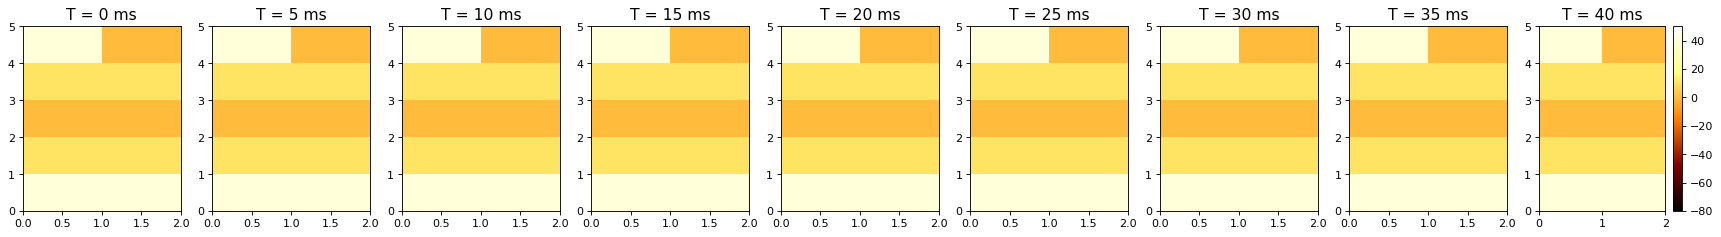

In [13]:
start_scope()

Width = 5
Height = 2
Layers = 1

neuron_count = Width * Height * Layers

eqns='''
v : 1
'''

G = NeuronGroup(neuron_count, eqns, method="exact")
G.v='10*((i%5)-2)**2'

S = StateMonitor(G, 'v', record=True)

run(100*ms)

plot_frames_flat(0, 0, 5, Width, Height, Layers, S.v, 'afmhot', 50, "Test")


If we examine the top right neuron in the system, it is quite clear that the neuron's plotted $v$ value is the $0$ all elements of $VoltageArray$ are initialized to rather than the correct value of $40$ taken by the neuron to its left in the plot. **This confirms the predicted off-by-one error.**

We may also notice that the function maps the $x$ axis in physical space onto the plot's $y$ axis and the $y$ axis from physical space onto the plot's $x$ axis.

Finally, the rightmost plot is a bit squished.

Let's now examine the body of the $ii$ for loop.

```python
xi = int(ii%Nx)
yi = int(floor(ii/Nx) - Ny*floor(ii/(Nx*Ny)))
if ii<(Ny*Nx):
    VoltageArray[xi][yi] = v[ii][time]
if ii>= (Ny*Nx):
    VoltageArray[xi][yi] = (VoltageArray[xi][yi] + v[ii][time])/2
```

The first equation for $xi$ is the well-covered equation which splits the neurons into lines parallel the physical x-axis.

The second equation for $yi$'s first element, $floor(ii/Nx)$, splits the x-aligned lines into a big long sheet. Then, the $-Ny*floor(ii/(Nx*Ny))$ element divides the long sheet into sheets of height $Ny$ and shifts them back to make a super-imposed sandwich.

The first $if$ statement looks for neurons on the first layer of the neuron block and uses their voltage values to populate $VoltageArray$. Due to the neuron indexing sequentially filling the neuron block layer by layer, the first $if$ statement will always be triggered first, followed by the second $if$ statement. Now the second $if$ statement acts for all neuron layers except the first layer and adds the current layer's voltage value to the existing stored value before dividing by $2$.

It seems prudent to examine whether this algorithm works for neuron blocks with more than $2$ layers. We can examine a neural column with $Width = Height = 1$ but $Layers = 3$.

| ii | VoltageArray |
| --- | --- |
| 0 | $v(0)$ |
| 1 | $\frac{v(0) + v(1)}{2}$ |
| 2 | $\frac{\frac{v(0) + v(1)}{2} + v(2)}{2} = \frac{v(0)}{4} + \frac{v(1)}{4} + \frac{v(2)}{2}$ |

So it appears that we are obtaining a weighted average rather than an unweighted average. I don't recall Kendall's paper specifying that a weighted average was used, but it's shouldn't substantially change the results.

Additionally of note is that the x-y axis mapping from physical to plot originates from filling the $VoltageArray$ with indices $[xi][yi]$ for $[row][column]$. A more intuitive mapping could've been achieved with $VoltageArray[yi][xi]$, though this might also suffer from having the plot reflected across the $y$ axis. If such artifacting occurs, it could probably be addressed by adjusting the $yi$ equation to $yi' = (Nx * Ny * Nz - 1) - yi$.

In [2]:
def plot_frames_flat_2(start, start_time, timestep, Nx, Ny, Nz, v, colorchoice, max, name):
    sum = 0.0
    initial = int(start/0.1)
    xi = 0
    yi = 0
    step = int(timestep/0.1)
    neurons = Nx * Ny * Nz
    myfig, myaxes = plt.subplots(nrows=1, ncols=10, figsize=(42, 3), dpi=80)
    for jj in range (0,9):
        time = initial + step * jj
        current_time = start_time + start + jj * timestep
        VoltageArray = np.zeros((Ny, Nx))
        for ii in range (0,neurons):
            xi = int(ii%Nx)
            yi = int(floor(ii/Nx) - Ny*floor(ii/(Nx*Ny)))
            VoltageArray[yi][xi] += v[ii][time]     
        VoltageArray /= Nz            
        title = 'T = ' + str(current_time) + ' ms'        
        plt.subplot(1,10,jj+1)
        mymesh = plt.pcolormesh(VoltageArray,cmap=colorchoice,vmin=-80,vmax=max)
        plt.title(title, fontsize = '14')
        if jj + 1 == 9:
            theax = myfig.add_subplot(1, 10, 10)
            myfig.colorbar(mymesh, theax)
    plt.show()

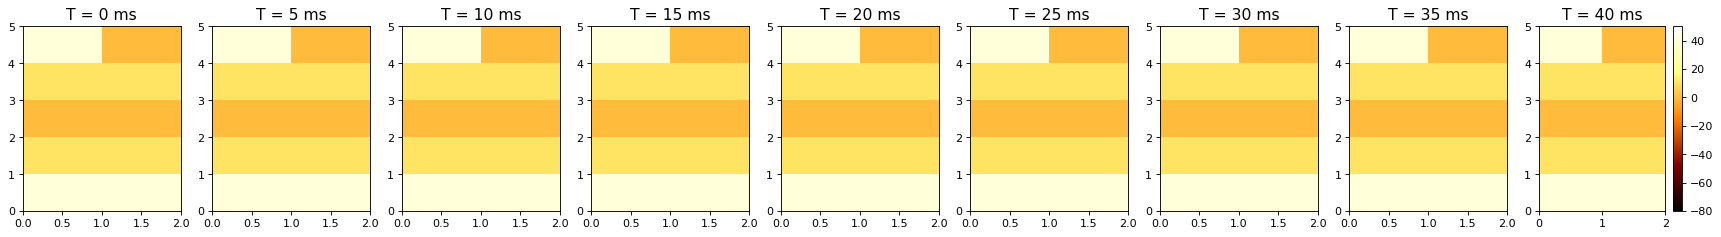

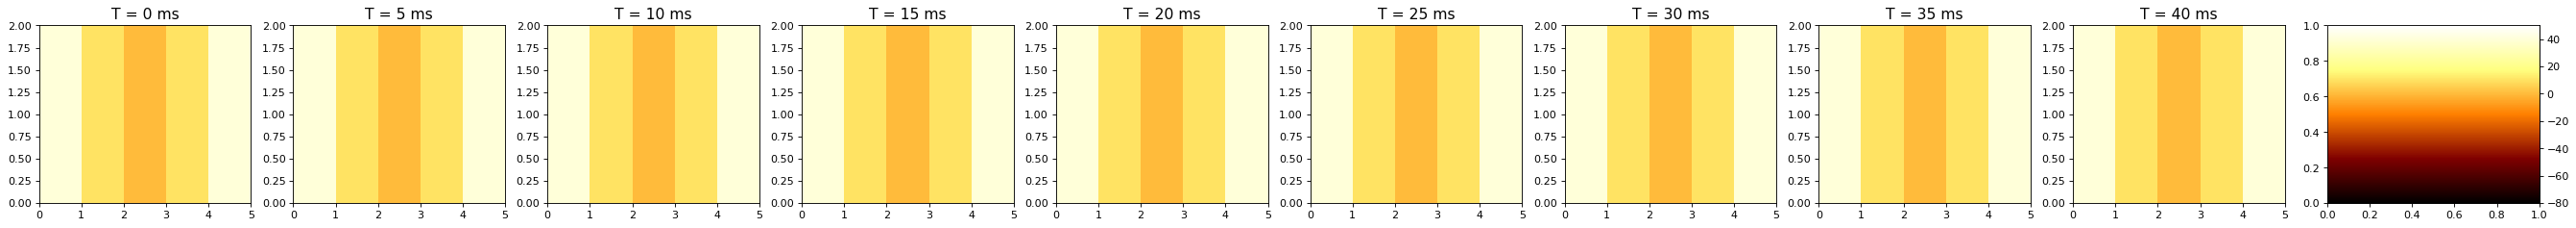

In [72]:
start_scope()

Width = 5
Height = 2
Layers = 1

neuron_count = Width * Height * Layers

eqns='''
v : 1
'''

G = NeuronGroup(neuron_count, eqns, method="exact")
G.v='10*((i%5)-2)**2'

S = StateMonitor(G, 'v', record=True)

run(100*ms)

plot_frames_flat(0, 0, 5, Width, Height, Layers, S.v, 'afmhot', 50, "Test")
plot_frames_flat_2(0, 0, 5, Width, Height, Layers, S.v, 'afmhot', 50, "Test 2")


Experimentally, numpy was sufficiently advanced that the $yi$ calculation need not be changed to remap the axis. However, the dimensions of $VoltageArray$ also needed to be switched to accomodate the reordered data set.

Through trial and error, $42$ appears to be a good width argument for the $np.figure()$ function. Unfortunately, due to the legend the last plot in each figure is always squished horizontally compared with its neighbors.

Bing Copilot suggests using $fig.legend$ to assign the legend to a figure rather than to a plot.

Had to rely on Bing AI . . .

Got it — you want to work with colormaps in Matplotlib, specifically with something like pcolormesh or imshow in a figure.
Here’s a complete, runnable Python example showing how to use a colormap (pcolormap) in a figure, including customization, colorbars, and normalization.

Example: Using a Colormap with pcolormesh

```python
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# Generate some example data
x = np.linspace(-3, 3, 100)
y = np.linspace(-3, 3, 100)
X, Y = np.meshgrid(x, y)
Z = np.sin(X**2 + Y**2)  # Example function

# Create a figure and axis
fig, ax = plt.subplots(figsize=(6, 5))

# Choose a colormap and normalization
cmap = cm.viridis  # You can try 'plasma', 'inferno', 'coolwarm', etc.
norm = Normalize(vmin=-1, vmax=1)  # Fix color scale range

# Create the pseudocolor plot
mesh = ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm, shading='auto')

# Add a colorbar
cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label('Function Value')

# Add labels and title
ax.set_xlabel('X-axis')
ax.set_ylabel('Y-axis')
ax.set_title('pcolormesh with Custom Colormap')

# Show the plot
plt.tight_layout()
plt.show()
```

Key Points:


Colormap (cmap)

You can use built-in colormaps like "viridis", "plasma", "coolwarm", "jet", etc.
Access via matplotlib.cm or directly by name.



Normalization (Normalize)

Controls how data values map to colors.
Normalize(vmin, vmax) fixes the color scale range.



shading='auto'

Ensures correct alignment between data points and color cells.



Colorbar

fig.colorbar() links the color scale to the plot for interpretation.




✅ Tip: If you want to reverse a colormap, append _r to its name, e.g., "viridis_r".

If you want, I can also show you how to apply multiple colormaps in the same figure or create a custom colormap for pcolormesh.
Do you want me to extend the example to that?


https://matplotlib.org/stable/users/explain/axes/arranging_axes.html was also helpful.

It is prudent to test whether the averaging function truly has an error, and whether my own implementation might have errors as well.

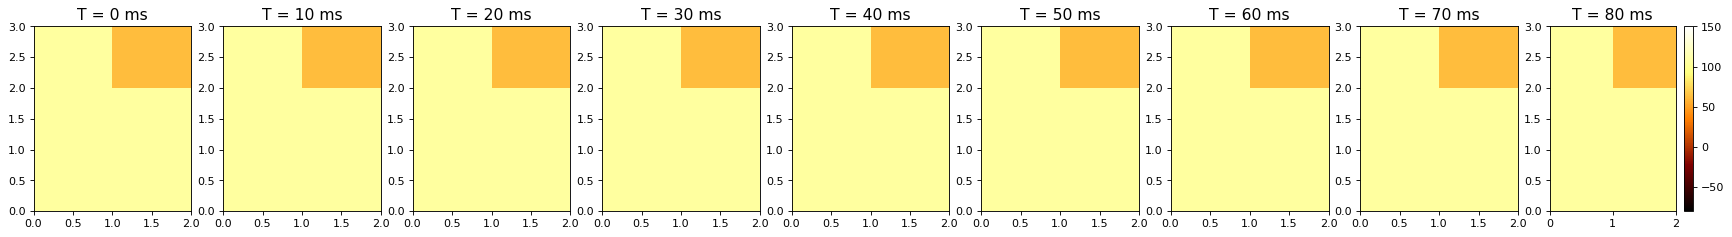

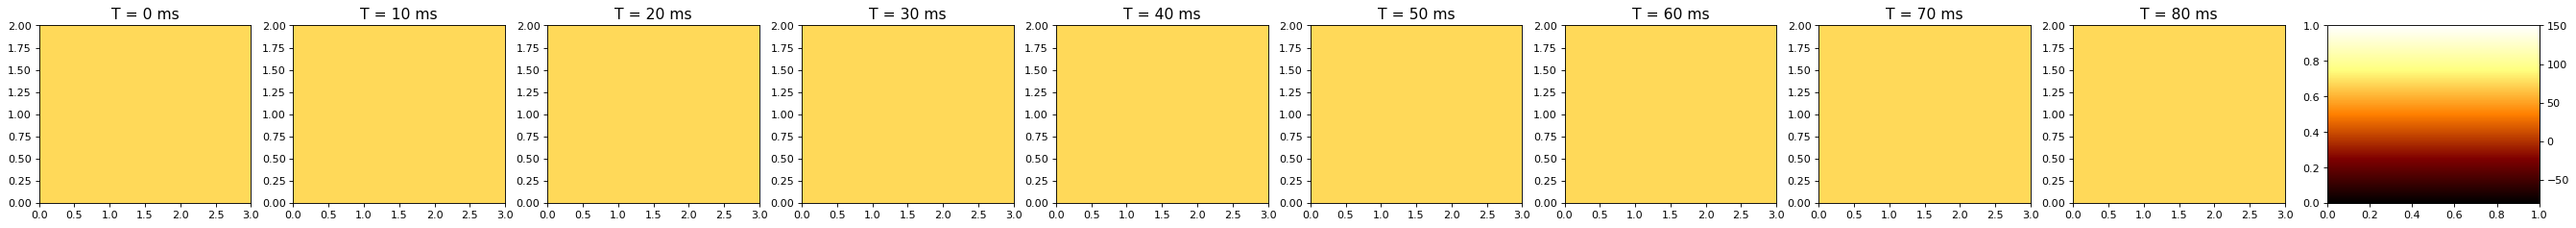

In [10]:
start_scope()

eqns = '''
v : 1
'''

Width = 3
Height = 2
Layers = 4
neuron_count = Width * Height * Layers


G = NeuronGroup(neuron_count, eqns, method="exact")

G.v = "50*(floor(i/(Width*Height)))"

S = StateMonitor(G, 'v', record=True)

run(100*ms)

plot_frames_flat(0, 0, 10, Width, Height, Layers, S.v, "afmhot", 150, "Kendall")
plot_frames_flat_2(0, 0, 10, Width, Height, Layers, S.v, "afmhot", 150, "LbZ")

At 4 neuron layers we clearly see a divergence in the average results of the two functions. With $G.v = "50*(floor(i/(Width*Height)))"$ we expect layer 1 to have $v = 0$, layer 2 to have $v = 50$, layer 3 to have $v = 100$, and layer 4 to have $v = 150$. So the unweighted average would be $v = 75$, which is closer to the 2nd function's dark orange ($v \approx 75$) than to the 1st function's light yellow ($v \approx 100$). While this difference would likely not matter much for real neuron blocks which are thin and should have relatively similar voltages in a column, were the code used to consider a microcolumn it might become a substantial issue. Of course, this function probably would not be used to analyze microcolumns without additional modification, such as allowing for finding the average over a specified set of layers rather than always finding the average over all layers in the neuron block.

## setup.py "class vectormap"

In [ ]:
# function for a directional divergence parameter
def dir_div_3D(SE_i, SE_j, SE_w, G_x, G_y, G_z, Nx , Ny , Nz):
    W = np.zeros((Nx,Ny,Nz))
    Wy = np.zeros((Nx,Ny,Nz))
    Wx = np.zeros((Nx,Ny,Nz))
    Wz = np.zeros((Nx,Ny,Nz))
    Nvals = np.zeros((Nx,Ny,Nz))
    
    for i in range(len(SE_i)):
        ival = SE_i[i]
        jval = SE_j[i]
        ipos = np.array([int(G_x[ival]),int(G_y[ival]),int(G_z[ival])])
        jpos = np.array([int(G_x[jval]),int(G_y[jval]),int(G_z[jval])])
        dpos = jpos - ipos
        dphat = dpos/(sqrt(dpos[0]**2 + dpos[1]**2 + dpos[2]**2))
        wvec = dphat * SE_w[i]
        W[ipos[0],ipos[1],ipos[2]] += SE_w[i]
        Wx[ipos[0],ipos[1],ipos[2]] += wvec[0]
        Wy[ipos[0],ipos[1],ipos[2]] += wvec[1]
        Wz[ipos[0],ipos[1],ipos[2]] += wvec[2]
        Nvals[ipos[0],ipos[1],ipos[2]] += 1
    
    for j in range(Nx):
        for k in range(Ny):
            for b in range(Nz):
                if W[j,k,b] != 0:
                    if Wx[j,k,b] != 0:
                        #Wx[j,k,b] = Wx[j,k,b]/(sqrt(Wx[j,k,b]**2 + Wy[j,k,b]**2 + Wz[j,k,b]**2))
                        Wx[j,k,b] = Wx[j,k,b]/(sqrt(Wx[j,k,b]**2 + Wy[j,k,b]**2))
                    if Wy[j,k,b] != 0:
                        #Wy[j,k,b] = Wy[j,k,b]/(sqrt(Wx[j,k,b]**2 + Wy[j,k,b]**2 + Wz[j,k,b]**2))
                        Wy[j,k,b] = Wy[j,k,b]/(sqrt(Wx[j,k,b]**2 + Wy[j,k,b]**2))
                    #if Wz[j,k,b] != 0:
                    #    Wz[j,k,b] = Wz[j,k,b]/(sqrt(Wx[j,k,b]**2 + Wy[j,k,b]**2 + Wz[j,k,b]**2))
    
    
    dir_div = []
    
    for x in range(Nx):
        for y in range(Ny):
            for z in range(Nz):
                if W[x,y,z]!=0:
                    if y > 1 and x > 1 and y < Ny-2 and x < Nx-2:
                        if z == 0:
                            for ll in range(3*3*2):
                                if W[x,y,z] != 0:
                                    xp = ll%3
                                    yp = floor(ll/3)%3
                                    zp = floor(ll/9)
                                    if ll != 4 and W[x-1+xp, y-1+yp, z+zp] != 0:
                                        xdot = Wx[x-1+xp, y-1+yp, z+zp] * Wx[x,y,z]
                                        ydot = Wy[x-1+xp, y-1+yp, z+zp] * Wy[x,y,z]
                                        #zdot = Wz[x-1+xp, y-1+yp, z+zp] * Wz[x,y,z]
                                        #dir_div.append(xdot+ydot+zdot)
                                        dir_div.append(xdot+ydot)
                        if z == 1:
                            for ll in range(3*3*3):
                                if Nvals[x,y,z] != 0:
                                    xp = ll%3
                                    yp = floor(ll/3)%3
                                    zp = floor(ll/9)
                                    if ll != 13 and W[x-1+xp, y-1+yp, z-1+zp] != 0:
                                        xdot = Wx[x-1+xp, y-1+yp, z-1+zp] * Wx[x,y,z]
                                        ydot = Wy[x-1+xp, y-1+yp, z-1+zp] * Wy[x,y,z]
                                        #zdot = Wz[x-1+xp, y-1+yp, z-1+zp] * Wz[x,y,z]
                                        #dir_div.append(xdot+ydot+zdot)
                                        dir_div.append(xdot+ydot)
                        if z == 2:
                            for ll in range(3*3*2):
                                if Nvals[x,y,z] != 0:
                                    xp = ll%3
                                    yp = floor(ll/3)%3
                                    zp = floor(ll/9)
                                    if ll != 13 and W[x-1+xp, y-1+yp, z-1+zp] != 0:
                                        xdot = Wx[x-1+xp, y-1+yp, z-1+zp] * Wx[x,y,z]
                                        ydot = Wy[x-1+xp, y-1+yp, z-1+zp] * Wy[x,y,z]
                                        #zdot = Wz[x-1+xp, y-1+yp, z-1+zp] * Wz[x,y,z]
                                        #dir_div.append(xdot+ydot+zdot)
                                        dir_div.append(xdot+ydot)
                                
    dir_corrected = []
    for i in range(len(dir_div)):
        if dir_div[i] != float('nan'):
            dir_corrected.append(dir_div[i])
    dir_return = np.mean(dir_corrected)
    return(dir_return)

This function computes a directional divergence paramter.

Its inputs are the input $SE\_i$, output $SE\_j$, and weights $SE\_w$ of a Synapses object, the neuron positions ${G\_x, G\_y, G\_z}$ from a NeuronGroup object initialized with those parameters, and the neuron block's dimensions ${Nx, Ny, Nz}$.

Of note is that ${SE\_i, SE\_j, SE\_w}$ are indexed by the synapse index due to the ability of neurons to be connected to/from multiple synapses. Synapse index is mostly handled in Brian's backend (see https://brian2.readthedocs.io/en/stable/user/synapses.html#technical-notes).

${W, Wx, Wy, Wz, Nvals}$ are 3D Numpy arrays initialized to the size of the neuron block.

The $i$ for loop cycles over each synapse in the synapse object and

1. ${ival, jval}$ finds the neuron index of the two synapse ends
2. ${ipos, jpos}$ assembles 1-by-3 numpy vectors/arrays containing the position data of the two synapse end neurons (to use vector math w/ numpy's fast c++ backend)
3. ${dpos, dphat}$ computes the displacement vector and then the displacement unit vector
4. $wvec$ scales the displacement unit vector by the synapse weight
5. ${W, Wx, Wy, Wz, Nvals}$ at the location of the neuron where the synapse in question begins, store the *running sum* of synapse weight vector magnitude, the weight vector cartesian coordinate components, and the number of synapses originating from that neuron.

The ${j, k, b}$ for loop cycles over each neuron in the neuron block. Considering the comments in this section of the code block, it is intended to find the unit vector for the sum of weight vectors originating from a neuron. Assuming that $Wz << {Wx, Wy}$, the current code is a decent approximation of this unit vector. (The code was likely adapted to conserve computational resources, though finding the mangitude of the unit vector a single time outside the if statement list probably would have been even cheaper and preserved a 3D result. Performing checks for whether the weight vector component is not $0$ might also be a waste of resources, given that the weight vector component equalling $0$ in all three dimensions is likely vanishingly low.)

$dir\_div$ is an empty python list for storing the ${x, y, z}$ for loop's results.

The ${x, y, z}$ for loop cycles over each neuron in the neuron block, but if statements are added which restrict the for loop's effective range to ignore a two layer thick neuron boundary in the x-y plane, with no such constraints along the z direction. (Again, not sure why you wouldn't just modify the for loop's range and avoid all these running 4 if statements on each loop iteration . . . but sure? If you toss this in c++ the compiler would fix everything; python wouldn't though, I think.) As in the ${j, k, b}$ for loop, there is an if statement to avoid calculations if the weight vector is null.

Internal behavior differs depending on the neuron's layer within the block because neurons on the top and bottom layers lack layers underneath to reference when calculating divergence. For thicker neuron blocks it may be worth the additional memory consumption of adding a layer of 0s on the top and bottom to simplify the code and reduce the if statements.

The $ll$ for loops mimic the effect of a triple nested for loop by manually indexing the for loop interations with ${xp, yp, zp}$. In this case I somewhat doubt this offers a substantial computational advantage over a triple nested for loop, but it is best practice? The equations for computing ${xp, yp, zp}$ are very similar to those for computing ${Gx, Gy, Gz}$ for the "pos_3D" class (without the random offsets). There are two if statements within each $ll$ loop--the first checks the central neuron's weight against $0$ for a second time (meaning it is completely extraneous) and the second performs double duty of checking each neighbor neuron's weight against $0$ (which still feels extraneous given how rare this condition should be) and preventing the $ll$ loop from considering the central neuron's weight vector. Finally, ${xdot, ydot}$ find a directional divergence contribution (divergence approximated by neighboring neuron weight unit vectors and this is dotted with the central weight unit vector) and append it to $dir\_div$. Ulitimately, this makes $dir\_div$ a very long list; in thicker systems it would have almost $27 - 1 = 26$ entries for each neuron in the neural block.

I would hope the final $dir\_corrected$ block is moot because the code does not seem like $NaN$ (not a number) would be an expected output. Regardless, this final $i$ loop searches for potential issues within $dir\_div$ and effectively removes them, enabling a smooth averaging process to obtain the entire function's return value, $dir\_return$.

In [ ]:
#vectormap for quasi-2D example
def vector_3D(Delt_SE, i, j, Nx, Ny, Nz, name):
    size = len(Delt_SE)
    length = int(Ny/5)
    width = int(Nx/5)
    x_pos = np.zeros(length * width)
    y_pos = np.zeros(length * width)
    x_mag = np.zeros(length * width)
    y_mag = np.zeros(length * width)
    N_array = np.zeros(length * width)
    for bb in range (length*width):
        x = bb%(width)
        y = floor(bb/width)
        x_pos[bb] = x
        y_pos[bb] = y
    for kk in range(int(size)):
        deltaW = Delt_SE[kk]
        xpre = i[kk]%Nx            
        xpost = j[kk]%Nx
        deltx = xpost - xpre
        ypre = floor(i[kk]/(Nx))%Ny
        ypost = floor(j[kk]/(Nx))%Ny
        delty = ypost - ypre
        zpre = floor(i[kk]/(Nx * Ny))
        zpost = floor(j[kk]/(Nx * Ny))
        deltz = zpost - zpre
        distxy = sqrt(deltx**2 + delty**2)
        dist = sqrt(deltx**2 + delty**2 + deltz**2)
        XW = 0.0
        YW = 0.0
        index = 0
        
        if delty == 0 and deltx == 0:
            continue
        
        XW = deltaW * (distxy/dist) * (deltx/distxy)
        YW = deltaW * (distxy/dist) * (delty/distxy)
        
        yspace = floor(i[kk]/(Nx * 5)) - floor(Ny/5) * floor(i[kk]/(Ny * Nx))   
        xspace = floor((i[kk]%Nx)/5)
        index = int(xspace + yspace * ((Nx)/5))
        
        x_mag[index] += XW
        y_mag[index] += YW
        N_array[index] += 1.0
        
    for ll in range (len(x_mag)):
        mag = sqrt(x_mag[ll]**2 + y_mag[ll]**2)
        x_mag[ll] = x_mag[ll] / N_array[ll]
        y_mag[ll] = y_mag[ll] / N_array[ll]
        
    for i in range(len(y_pos)):
        y_pos[i] = y_pos[i] * 5
        x_pos[i] = x_pos[i] * 5
        
    xtick = np.arange(0,110,10)
    ytick = np.arange(0,110,10)
        
    plt.figure(figsize=(10, 10), dpi=80)
    plt.quiver(y_pos, x_pos, y_mag, x_mag)
    plt.title(r'$\vec{\Delta W}$', fontsize = '26')
    plt.xlabel('X', fontsize = '20')
    plt.ylabel('Y', fontsize = '20')
    plt.xticks(xtick, fontsize = '18')
    plt.yticks(ytick, fontsize = '18')
    plt.show()
    
    return([y_pos, x_pos, y_mag, x_mag])

This function is intended to produce a *sparse* map of the neuron system's weight vectors such as the "weight change vector field" shown in Figure 3.1 from Butler's dissertation.

This function is not used in any of the Wave_1.py etc. files, making it difficult to ascertain what objects it expects for its input arguments (of which two arguments ${Nz, name}$ are evidently not needed).

By inspection, ${i, j}$ appear to be Synapse output objects for the originating neuron index and the terminating neuron index; i.e. dir_div_3D's ${SE\_i, SE\_j}$. Similarly, $Delt\_SE$ is probably the Synpase output object for synaptic weight. As in other functions, ${Nx, Ny}$ are the neuron block's width and height.

$size$ is the number of synapses in the system.

${length, width}$ are the width and height of a neuron block which has been condensed by a factor of 5 in the xy plane.

${x\_pos, y\_pos, x\_mag, y\_mag}$ are the neuron lattice positions of the condensed system, the summed 2D projections of the weight vectors for those lattice positions, and the number of synapses from the original system which contributed to each neuron of the condensed system.

The $bb$ for loop computes the lattice positions of the condensed system ${x\_pos, y\_pos}$ through the standard formulas also used in pos_3D's ${x, y, z}$ members.

The $kk$ for loop cycles over all of the original neuron block's synapses (python's len function should naturally give an int, so the recasting of $size$ for the range function seems extraneous). This loop's first section covers the following operations:

1. Obtain the weight vector magnitude from $Delt\_SE$
2. Obtain the positions of the synapse's originating ${xpre, ypre, zpre}$ and terminating ${xpost, ypost, zpost}$ neurons
3. Compute the distance $dist$ and its xy-plane projection $distxy$ between the synaptice terminals via a component method ${deltx, delty, deltz}$

${XW, YW}$ from within the $kk$ loop are the components of the vector formed by scaling the synapse displacement direction by its weight. (Their computation multiplies by $\frac{deltxy}{deltxy}$ which means finding $deltxy$ was extraneous computation . . .) $index$ is the (1D) index of the condensed system's neuron which the original system's synapse is mapped to. The ${xspace, yspace}$ variables exist entirely to make the $index$ computation more legible.

The $kk$ loop's if statement enforces that only if at least one of ${deltx, delty}$ is non-zero are the ${x\_mag, y\_mag, N\_array}$ running sums for the relevant condensed system neuron incremented/summed. **This appears to cause the averageing of the synaptic weight vectors at each condensed system neuron to be a bad average, because in theory $\vec{0}$ weight vectors should also contribute to the average by incrementing $N\_array$?** But as mentioned before, most weight change vectors are not expected to be $\vec{0}$ so the average is likely not overly far from the true average.

The $ll$ for loop *attempts* to average the condensed system's synaptic weight vectors. $mag$ appears to be an extraneous variable from a presumed version of the code which plotted weight change unit vectors.

The $i$ for loop scales up the condensed system to match the original system in dimension.

Finally, the function generates but does not save a plot f the condensed system's averaged weight vectors and exports/returns the set of arrays used to generate the plot.

## setup.py "class reg_synapse"

In [ ]:
#regular current-input synapse
class reg_synapse:
    eqns = '''
    w : 1
    '''
    on_pre='''
    I_post += w
    ''' 

This class contains only two members, both string variables used as arguments when initializing a Synapses object. $eqns$ lists any extra synapse member variables and/or equations besides default existing variables such as $delay$, and $on_pre$ specifies code to be executed when the pre-synaptic neuron experiences a spike. In this case, $I\_post += w$ means that the post-synaptic neuron should have a current injection equal to the synaptic weight $w$.

## setup.py "class STDP1"

In [ ]:
#Regular STDP, no Inhibitory Rules, No Metaplasticity
class STDP1:
    eqns = '''
    w : 1
    dapre/dt = -apre/tau_pre : 1 (event-driven)
    dapost/dt = -apost/tau_post : 1 (event-driven)
    xdist : 1
    ydist : 1
    zdist : 1
    dist : 1
    '''
    on_post='''
    apost += Apost
    w = clip(w+apre, 0, wmax)
    '''
    on_pre='''
    I_post += w
    apre += Apre 
    w = clip(w+apost, 0, wmax)
    '''
    inhib = '''
    w : 1
    '''
    pre_inhib = ''' 
    I_post += w 
    '''

This class contains only five string members. ${eqns, on\_post, on\_pre}$ are arguments for synapses originating from excitory neurons whilst ${inhib, pre\_inhib}$ are arguments for synapses originating from inhibitory neurons. The ${inhib, pre\_inhib}$ arguments are used interchangeably with the corresponding ${eqns, on\_pre}$ arguments from the reg_synapse class.

From $eqns$ the ${xdist, ydist, zdist, dist}$ member variables do not seem to be referenced/used in any of the Wave_1.py and etc. files. They are likely residual code from a separate version of this class.

$w$ is again the synaptic weight.

${tau\_pre, tau\_post, Apost, Apre, w_max}$ are all defined in the Wave_1.py etc. files. In those files ${Apre, Apost}$ are generally linked to an argument $RATE$ passed into the $Wave_1.py()$ and etc. functions defined in those files.

${dapre/dt, dapost/dt}$ are somewhat standard exponential decay equations for spike timing dependent plasticity which may be found at https://brian2.readthedocs.io/en/stable/resources/tutorials/2-intro-to-brian-synapses.html, albeit in this case $w$ is generates a decaying current in post-synaptic neurons rather than directly affecting those neuron's voltage. The "event-driven" tag means that these exact differential equations are only computed for the current values of ${apre, apost}$ just before ${on\_post, on\_pre}$ is activated.

Of some note is that in the $on\_pre$ member variable, $I\_post += w$ occurs before $w$ is changed, meaning plasticity does not affect the response to the spike which activates plasticity. Additionally, the value of $w = w + apost$ is "clipped" to be within the range $0 \leq w \leq wmax$. Dr. Cruz has suggested adjusting this into a form $w = w + apost * e^{-\frac{|w + apost|}{w_0}}$, which should produce a more sigmoidal cutoff.

# Section 2 "Wave_1.py"

The central simulation.

In [ ]:
from brian2 import *
from math import exp, floor, sqrt
from matplotlib.pyplot import *   
from setup import izzy, pos_3D, STDP1, reg_synapse, vectormap #removed write_video function not found in setup.py and seemingly not used here either

Import statements for needed libraries.

In [ ]:
def Wave(seednum, batch, RATE):
    
    #setting the random seed based on input
    seed(seednum)

The Wave_1.py file contains a single function, $Wave$ taking three arguments. $seednum$ is used to seed a random number generator for replicability, $batch$ determines the directory where the output data is saved, and $RATE$ adjusts the speed of spike timing dependent plasticity with a recommended range of $[0, 4]$.

In [ ]:
#names for numpy '.npy' datafiles (missing numbers are due to the removal of a few originally measured quantities)
vidName = str(batch) +  '/' + str(batch) + str(seednum) + '.avi'
fileName1 = str(batch) +  '/' + str(batch) + str(seednum) + 'rate.npy'
fileName2 = str(batch) +  '/' + str(batch) + str(seednum) + 'trials.npy'
fileName3 = str(batch) +  '/' + str(batch) + str(seednum) + 'div.npy'
fileName4 = str(batch) +  '/' + str(batch) + str(seednum) + 'vector.npy'
fileName5 = str(batch) + '/' + str(batch) + str(seednum) + 'speed.npy'
fileName6 = str(batch) + '/' + str(batch) + str(seednum) + 'order.npy'
fileName9 = str(batch) + '/' + str(batch) + str(seednum) + 'dw_dist.npy'
fileName10 = str(batch) + '/' + str(batch) + str(seednum) + 'dw_std.npy'

#Define dimensionality of Network
Height = 100
Width = 100
Layers = 3
N = Height * Width * Layers

#Define length of simulation
sim_t = 100000*ms

#connectivity constants
#K - range of possible weights
K = 11.0
#C - controls the maximum connection probability
C = 0.6
#lambda - controls the characteristic length of neuronal connectivity
lamb = 2.5

#Proportion excitatory neurons
Percent_ecn = 0.8

#Time-decay of current inputs
tau = 4*ms

#Sub-Threshold Background (random stimulation)
STIMRANGE = 0.5
stim_freq = 100.0*Hz

#Center Stimulation
SpecStim = 4.0
SpecFreq = 500.0*Hz

#Multiplier for scale of distance dependent time-delay
DELAYMULT = 0.5

#Proportion of space neurons can move between one another (random positioning)
rand_pos = 0.0

#STDP Constants for Excitatory Neurons
tau_pre = 16.8*ms
tau_post = 33.7*ms 
rate = RATE
Apre = 0.0016*rate
Apost = -Apre
wmax = 0.5*K

print('Izhikevich Model...')
#define izhikevich model (current modeled as a differential equation with uniform time-decay constant tau)
eqns = izzy.eqns
res = izzy.res
thresh = izzy.thresh

a_inhib = izzy.a_inhib
b_inhib = izzy.b_inhib
c_inhib = izzy.c_inhib
d_inhib = izzy.d_inhib
a_ecn = izzy.a_ecn
b_ecn = izzy.b_ecn
c_ecn = izzy.c_ecn
d_ecn = izzy.d_ecn

Most of the above code involves setting variables, many of which are extracted from the setup.py's izzy class.

The $print('Izhikevish Model...')$ statement exists to notify users that the program has booted.

In [ ]:
#determining which neurons are excitatory
excitatory, inhibitory = izzy.ecn_inhib_init(N, Percent_ecn)

#Create array of neurons with pre-defined threshold/spiking behavior
G = NeuronGroup(N, eqns, threshold = thresh, reset = res, method = 'euler')

#setting excitatory and inhibitory neuron parameters
if len(inhibitory) > 0:
    G.ecn[inhibitory] = '0'
    G.a[inhibitory] = izzy.a_inhib
    G.b[inhibitory] = izzy.b_inhib
    G.c[inhibitory] = izzy.c_inhib
    G.d[inhibitory] = izzy.d_inhib

if len(excitatory) > 0:
    G.ecn[excitatory] = '1'
    G.a[excitatory] = izzy.a_ecn
    G.b[excitatory] = izzy.b_ecn
    G.c[excitatory] = izzy.c_ecn
    G.d[excitatory] = izzy.d_ecn

#Initialize voltage and recovery variable values
G.v = izzy.rest
G.u = izzy.restu

#Create positional x,y,z coordinates w/random displacement from lattice positions
G.x = pos_3D.x
G.y = pos_3D.y
G.z = pos_3D.z

#Create a single poisson point process per neuron for random stimulation (background)
P = PoissonGroup(N, stim_freq)

#create poisson inputs for the bursts of central stimulation
P1_Spec = PoissonGroup(192, SpecFreq)

#Connect 1 point process to each neuron. Different range of stimulation currents for inhibitory and excitatory
PS = Synapses(P,G,on_pre = izzy.stim_type)
PS.connect(j='i')

#connecting the central stimulation spike trains to the correct neurons (only works for 100X100)
P1S = Synapses(P1_Spec, G, on_pre = izzy.stim_type3)
P1S.connect(j = 'int((Width*Height)*(floor(i/64))+ (46 + floor(i/8)%8)*Width + (46 + i%8))')

#creating the excitatory (SE) and inhibitory (SI) synapses
SE = Synapses(G, G, STDP1.eqns, on_pre = STDP1.on_pre, on_post = STDP1.on_post)
SI = Synapses(G,G, reg_synapse.eqns, on_pre = reg_synapse.on_pre)

#distance-dependent connection probability
SE.connect(condition='i!=j', p = izzy.SE_prob)
SI.connect(condition='i!=j', p = izzy.SI_prob)

#different range of randomly initialized weights for excitatory and inhibitory
SE.w = izzy.SE_w
SI.w = izzy.SI_w

#distance dependent time-delay
SI.delay = izzy.delay
SE.delay = izzy.delay

These statements serve to initialize the simulation objects, and most of it is straightforward.

Notable code:
* The initialization of $G.ecn$, as this code was used to determine the meaning of the izzy class's $ecn$ member variable.
* The second PoissonGroup has $192 = 8 * 8 * 3$ inputs.
* The statement for assigning the second PoissonGroup to neurons, restated below.

```python
P1S.connect(j = 'int((Width*Height)*(floor(i/64))+ (46 + floor(i/8)%8)*Width + (46 + i%8))')
```

From setup.pos_3D we know that neuron index fills the neuron block in lines along x which form planes along y which are stacked into layers along z. From the Wave_1.py comments we know these 192 poisson inputs need to be mapped to the 8x8x3 neuron sub-block in the middle of a 100x100x3 neuron block with a 1-to-1 correspondance.

Arguably the easiest method of connecting these is to use a list
```python
P1S.connect(i=[0, 1, 2], j=[4646, 4647, 4648])
```
where the first $j$ index comes from $100*(\frac{100 - 8}{2}) + \frac{100 - 8}{2}$, and the list would become more complicated later on due to needing to skip from line to line and from layer to layer.

Butler instead uses geometry/mathematics to write a function achieving the same purpose. The $floor(i/64)$ divides $i$ into 3 layers of $64$ inputs each, and this layer index is multiplied by the whole system's $100 * 100$ neurons per layer to push $j$ between layers. Similarly, the second term $floor(i/8)%8$ finds the $y$ index within the neuron sub-block. Multiplying this by $Width$ allows for changing $y$ index of the full neuron block, and adding $46 * Width$, or better $(Length - 8)/2 * Width$, adds a $y$ offset of $46$ to push the sub-block into the center of full block. Finally, the $46 + i%8$ term computes the z-index of the sub-block and translates it with a $46$ neuron offset (better as $(Width - 8)/2$) into the center of the full block.

This statment shows that the simplist method of designing these synaptic connection statements is to think in terms of coordinates and coordinate transformations rather than "how many neurons do I need to jump forward at the end of this segment of continuous indices".

In [ ]:
#saving initial weights and indices for vectorfield plot
SEpre = []
SEi = []
SEj = []
for i in range (len(SE.w)):
    SEpre.append(SE.w[i])
    SEi.append(SE.i[i])
    SEj.append(SE.j[i])

#creating empty lists for various saved quantities
trials = []
div = []
rate = []
dir_save = []
speeds = []
dw_dist = []
dw_std = []

#directional local order calculation
div.append(izzy.props_div(SE.w,K))
nonzeros = (SE.w != 0.0)
nonzero = np.sum(nonzeros)
dir_save.append(vectormap.dir_div_3D(SE.i,SE.j,SE.w,G.x,G.y,G.z,Width,Height,Layers))

Nsteps = int((sim_t/ms)/1000) + 1
Rates = PopulationRateMonitor(G)
time = 0.0
for i in range(Nsteps):
    trial = i+1
    
    Wpre = []
    for ll in range(len(SE.w)):
        Wpre.append(SE.w[ll])
    Wpre = np.array(Wpre)
    

    SPIKES = SpikeMonitor(G)
    run (30 * ms)
    Rates = PopulationRateMonitor(G)
    if trial%10 == 0:
        #voltage saving for periodic plotting of behavior
        Voltage = StateMonitor(G, 'v', record=True)
    run(100*ms)
    rate.append(mean(Rates.rate/Hz))
    speeds.append(izzy.speed(time+30,SPIKES.i,SPIKES.t/ms,G.x,G.y,G.z))
    del(Rates)
    del(SPIKES)
    run(50*ms)
    if trial%10 == 0:
        #plotting behavior
        title = str(batch) + '/trial' + str(trial) + '_seed' + str(seednum) + '.png'
        pos_3D.plot_frames_flat(0, trial*1000 + 30, 15, Width, Height, Layers, Voltage.v, 'afmhot', -40, title)
        del(Voltage)
    run(820*ms)
    div.append(izzy.props_div(SE.w,K))
    dir_save.append(vectormap.dir_div_3D(SE.i,SE.j,SE.w,G.x,G.y,G.z,Width,Height,Layers))
    trials.append(trial)
    
    Wpost = []
    for ll in range(len(SE.w)):
        Wpost.append(SE.w[ll])
    Wpost = np.array(Wpost)

        
    dwvals = Wpost - Wpre
    dw_dist.append(np.mean(dwvals))
    dw_std.append(np.std(dwvals))

    time += 1000.0

This is the function's main simulation execution loop.

It appears that ${SEpre, SEi, SEj}$ variables are for producing vector maps with setup.vectormap.vector_3D in a separate python program.

Notes:
* for the $ll$ for loop, does $numpy.array(SE.w)$ not work?
* voltage plot series are made once every $10000 ms$ and begin collecting data $30 ms$ into the $1000 ms$ loop interval; data collection continues for $150 ms$
* wave speed is computed $130 ms$ into each simulation loop using spike timing history starting from $30 ms$ into that loop
* Brian2 objects are deleted when their purpose concludes (unless the program is terminating immediately afterwards) to save memory
* PopulationRateMonitor finds the average, instantaneous population firing rate at a time-step and records them in memory.
* the proportion of diverged synapses and the population's directional divergence are only computed at the end of each $1000 ms$ interval
* $dwvals$ is the weight change over a single $1000 ms$ loop

The wave speed, voltage plot series, and population rate monitor observation period all occur early in the simulation loop likely because the stimulation-driven wave is expected to complete it's travel to the edge of the simulation in this period.

In [ ]:
#saving various measured quantities
np.save(fileName1, rate)
np.save(fileName2, trials)
np.save(fileName3, div)
np.save(fileName5, speeds)
np.save(fileName6, dir_save)
np.save(fileName9, dw_dist)
np.save(fileName10, dw_std)

deltaSE = []              
for j in range(len(SE.w)):
    deltaSE.append(SE.w[j] - SEpre[j])

np.save(fileName4, [deltaSE,SEi,SEj])

These lines save simulation data into files. The filenames were defined at the beginning of the code file.

It is interesting that $deltaSE$ is only calculated once for the entire simulation.

# Section 3 "Wave_2.py"

The stochastic simulation.

In [ ]:
from brian2 import *
from math import exp, floor, sqrt
import matplotlib.pyplot as plt
import numpy as np
from setup import izzy, pos_3D, STDP1, vectormap #removed write_video function not found in setup.py and seemingly not used here either

def Wave(seednum, batch, RATE):
    seed(seednum)
    vidName = str(batch) +  '/' + str(batch) + str(seednum)
    fileName1 = str(batch) + '/' + str(batch) + str(seednum) + 'rate.npy'
    fileName2 = str(batch) + '/' + str(batch) + str(seednum) + 'div.npy'
    fileName3 = str(batch) + '/' + str(batch) + str(seednum) + 'times.npy'
    fileName4 = str(batch) + '/' + str(batch) + str(seednum) + 'vector.npy'
    fileName6 = str(batch) + '/' + str(batch) + str(seednum) + 'order.npy'

    #Define dimensionality of Network
    Height = 100
    Width = 100
    Layers = 3
    N = Height * Width * Layers

    #Define length of simulation
    sim_t = 30000*ms

    #connectivity constants
    #K - controls range of initial weights
    K = 11.0
    #C - controls maximum connection probability
    C = 0.6
    #lambda - controls the characteristic connectivity length
    lamb = 2.5

    #Proportion excitatory neurons
    Percent_ecn = 0.8

    #Time-decay of current inputs
    tau = 4*ms

    #Range of input current and frequency from Poisson Point Processes (random stimulation)
    STIMRANGE = 1.8
    stim_freq = 180.0*Hz

    #Multiplier for scale of distance dependent time-delay
    DELAYMULT = 0.5

    #Proportion of space neurons can exist between one another (random positioning)
    rand_pos = 0.0

    #STDP Constants for Excitatory Neurons (ignore if not using an STDP synapse model)
    tau_pre = 16.8*ms
    tau_post = 33.7*ms
    rate = float(RATE)
    Apre = 0.0016*rate
    Apost = -Apre
    wmax = 0.5*K

    #define izhikevich model (current modeled as a differential equation with uniform time-decay constant tau)
    eqns = izzy.eqns
    res = izzy.res
    thresh = izzy.thresh

    a_inhib = izzy.a_inhib
    b_inhib = izzy.b_inhib
    c_inhib = izzy.c_inhib
    d_inhib = izzy.d_inhib
    a_ecn = izzy.a_ecn
    b_ecn = izzy.b_ecn
    c_ecn = izzy.c_ecn
    d_ecn = izzy.d_ecn

    #determining which neurons are excitatory
    excitatory, inhibitory = izzy.ecn_inhib_init(N, Percent_ecn)

    #Create array of neurons with pre-defined threshold/spiking behavior
    G = NeuronGroup(N, eqns, threshold = thresh, reset = res, method = 'euler')

    #if statements to set up the parameters of excitatory and inhibitory neurons based on the original Izhikevich paper
    #'simple model of spiking neurons'
    if len(inhibitory) > 0:
        G.ecn[inhibitory] = '0'
        G.a[inhibitory] = izzy.a_inhib
        G.b[inhibitory] = izzy.b_inhib
        G.c[inhibitory] = izzy.c_inhib
        G.d[inhibitory] = izzy.d_inhib

    if len(excitatory) > 0:
        G.ecn[excitatory] = '1'
        G.a[excitatory] = izzy.a_ecn
        G.b[excitatory] = izzy.b_ecn
        G.c[excitatory] = izzy.c_ecn
        G.d[excitatory] = izzy.d_ecn


    #Initialize voltage 'v' and recovery variable 'u' values
    G.v = izzy.rest
    G.u = izzy.restu

    #Create positional x,y,z coordinates w/random displacement from lattice positions
    G.x = pos_3D.x
    G.y = pos_3D.y
    G.z = pos_3D.z

    #Create a single poisson point process per neuron for random stimulation
    P = PoissonGroup(N, stim_freq)

    #Connect 1 point process to each neuron. Different range of stimulation currents for inhibitory and excitatory
    PS = Synapses(P,G,on_pre = izzy.stim_type)
    PS.connect(j='i')

    #create excitatory and inhibitory synapses between neurons
    SE = Synapses(G, G, STDP1.eqns, on_pre = STDP1.on_pre, on_post = STDP1.on_post)
    SI = Synapses(G,G, STDP1.inhib, on_pre = STDP1.pre_inhib)

    #distance-dependent connection probability
    SE.connect(condition='i!=j', p = izzy.SE_prob)
    SI.connect(condition='i!=j', p = izzy.SI_prob)

    #different range of random weights for excitatory and inhibitory
    SE.w = izzy.SE_w
    SI.w = izzy.SI_w

    #distance dependent time-delay
    SI.delay = izzy.delay
    SE.delay = izzy.delay

    #excitatory weight arrays
    SE_pre = []
    SE_i = []
    SE_j = []
    deltaSE = []

    #for saving of initial excitatory weights
    for i in range (len(SE.w)):
        SE_pre.append(SE.w[i])
        SE_i.append(SE.i[i])
        SE_j.append(SE.j[i])

    #various empty lists for saved quantities
    #the network population firing rate for each 100 ms period
    rate = []
    #starting time for each 100 ms datapoint
    times = []
    #divergence of weights
    div = []
    #local directional order of synaptic weights
    dir_save = []

    Nsteps = int((sim_t/ms)/100)
    time = 0.0 

    div.append(izzy.props_div(SE.w,K))
    
    Rates = PopulationRateMonitor(G)
    for i in range(Nsteps):
        if i ==5 or i == 100 or i == 200 or i == 250:
            #saving network activity for plots
            Voltage = StateMonitor(G,'v',record=True)
        run(100*ms)
        time += 100
        if i ==7 or i == 102 or i == 202 or i == 252:
            #plotting network activity
            name = str(batch) + '/' + str(seednum) + '_' + str(i) + '.png'
            pos_3D.plot_frames_flat(0, i*100, 15, Width, Height, Layers, Voltage.v, 'afmhot', -40, name)
            del(Voltage)
        rate.append(np.mean(Rates.rate/Hz))
        del(Rates)
        times.append(time)
        dir_save.append(vectormap.dir_div_3D(SE.i,SE.j,SE.w,G.x,G.y,G.z,Width,Height,Layers))
        div.append(izzy.props_div(SE.w,K))
        Rates = PopulationRateMonitor(G)
        print('percent complete = ', 100.0*((i+1)/Nsteps))
        

    filename11 = str(batch) +  '/' + str(batch) + str(seednum) + 'wdist.npy'
    np.save(filename11, [w1vals, w2vals, w3vals])
        
    #saving relevant quantities
    np.save(fileName1, rate)
    np.save(fileName2, div)
    np.save(fileName3, times)
    np.save(fileName6, dir_save)

    #saving change in weights for vectorplots
    for j in range(len(SE.w)):
        deltaSE.append(SE.w[j] - SE_pre[j])
    np.save(fileName4, [deltaSE, SE_i, SE_j])

Notable features of Wave_2.py:
1. There is only 1 Poisson Group process, the background stimulation, but the ${STIMRANGE, stim\_freq}$ of ${1.8, 180 Hz}$ are both much higher than in Wave_1.py ${0.5, 100 Hz}$.
2. Simulation length is shorter than Wave_1.py, at only $30000 ms$
3. Inhibitory synapse object actually uses the STDP1 class
4. Main loop's steps are only $100 ms$ each
5. Due to the shortened loop length, the $plot\_frames\_flat$ function now runs over multiple loops and has an altered recording condition.
6. **Error** The start time of $plot\_frames\_flat$ is $0$ with respect to the initialization of the StateMonitor object, and that would be $500 ms$ for $i == 5$ due to the existence of the $i = 0$ loop. The plotting function is called at $i == 7$ after the loop's run statement, giving the StateMonitor a $300 ms$ long history to draw upon. But this history begins at $500 ms$ and not the codes' $(i == 7) * 100 ms = 700 ms$ offset provided to the function.
7. Main loop has an additional simulation progress print statement
8. **Error** in the first $np.save$ command, the ${w1vals, w2vals, w3vals}$ variables were never initialized. Since the filename is "wdist.npy", it appears reasonable that this is meant to contain the proportion of diverged weight information also contained in $fileName2$.

In [7]:
import os
filename =os.path.join(os.path.curdir, 'test.npy')
np.save(filename, [w1vals])

NameError: name 'w1vals' is not defined

In theory, this should've prevented the Wave_2.py file from running, and I believe that was the case; in earlier testing I probably removed stochastic testing but did not update my Github file.

# Section 4 "Wave_3.py"

The alternating simulation.

In [ ]:
from brian2 import *
from math import exp, floor, sqrt
from matplotlib.pyplot import *   
from setup import izzy, pos_3D, STDP1, reg_synapse, vectormap #removed write_video and wave_propagation function not found in setup.py and seemingly not used here either

def Wave(seednum,batch, RATE):
    seed(seednum)
    
    vidName = str(batch) +  '/' + str(batch) + str(seednum) + '.avi'
    fileName1 = str(batch) +  '/' + str(batch) + str(seednum) + 'rate.npy'
    fileName2 = str(batch) +  '/' + str(batch) + str(seednum) + 'trials.npy'
    fileName3 = str(batch) +  '/' + str(batch) + str(seednum) + 'div.npy'
    fileName4 = str(batch) +  '/' + str(batch) + str(seednum) + 'vector.npy'
    fileName6 = str(batch) + '/' + str(batch) + str(seednum) + 'order.npy'
    
    #Define dimensionality of Network
    Height = 100
    Width = 100
    Layers = 3
    N = Height * Width * Layers

    #Define length of simulation
    sim_t = 100000*ms

    #connectivity constants
    #K - controls the initial range of weights
    K = 11.0
    #C - controls the maximum connection probability
    C = 0.6
    #lambda - controls the characteristic connectivity length
    lamb = 2.5

    #Proportion excitatory neurons
    Percent_ecn = 0.8

    #Time-decay of current inputs
    tau = 4*ms

    #Sub-Threshold Background (random stimulation)
    STIMRANGE = 0.5
    stim_freq = 100.0*Hz

    #Center Stimulation
    SpecStim = 4.0
    SpecFreq = 500.0*Hz

    #Multiplier for scale of distance dependent time-delay
    DELAYMULT = 0.5

    #Proportion of space neurons can move between one another (random positioning)
    rand_pos = 0.0

    #STDP Constants for Excitatory Neurons
    tau_pre = 16.8*ms
    tau_post = 33.7*ms
    rate = float(RATE)
    Apre = 0.0016*rate
    Apost = -Apre
    wmax = 0.5*K

    #define izhikevich model (current modeled as a differential equation with uniform time-decay constant tau)
    eqns = izzy.eqns
    res = izzy.res
    thresh = izzy.thresh

    a_inhib = izzy.a_inhib
    b_inhib = izzy.b_inhib
    c_inhib = izzy.c_inhib
    d_inhib = izzy.d_inhib
    a_ecn = izzy.a_ecn
    b_ecn = izzy.b_ecn
    c_ecn = izzy.c_ecn
    d_ecn = izzy.d_ecn

    #determining which neurons are excitatory
    excitatory, inhibitory = izzy.ecn_inhib_init(N, Percent_ecn)

    #Create array of neurons with pre-defined threshold/spiking behavior
    G = NeuronGroup(N, eqns, threshold = thresh, reset = res, method = 'euler')

    #if statements to set up the parameters of excitatory and inhibitory neurons based on the original Izhikevich paper
    #'simple model of spiking neurons'
    print('Setting model parameters...')
    if len(inhibitory) > 0:
        G.ecn[inhibitory] = '0'
        G.a[inhibitory] = izzy.a_inhib
        G.b[inhibitory] = izzy.b_inhib
        G.c[inhibitory] = izzy.c_inhib
        G.d[inhibitory] = izzy.d_inhib

    if len(excitatory) > 0:
        G.ecn[excitatory] = '1'
        G.a[excitatory] = izzy.a_ecn
        G.b[excitatory] = izzy.b_ecn
        G.c[excitatory] = izzy.c_ecn
        G.d[excitatory] = izzy.d_ecn


    #Initialize voltage values
    G.v = izzy.rest
    G.u = izzy.restu

    #Create positional x,y,z coordinates w/random displacement from lattice positions
    G.x = pos_3D.x
    G.y = pos_3D.y
    G.z = pos_3D.z

    #Create a single poisson point process per neuron for random stimulation
    P = PoissonGroup(N, stim_freq)
    
    #creating poisson point process spike trains for the top and bottom stimulation locations
    P1_Spec = PoissonGroup(192, SpecFreq)
    P2_Spec = PoissonGroup(192, SpecFreq)


    #Connect 1 point process to each neuron. Different range of stimulation currents for inhibitory and excitatory
    PS = Synapses(P,G,on_pre = izzy.stim_type)
    PS.connect(j='i')

    #connecting point stimulation to the correct areas
    P1S = Synapses(P1_Spec, G, on_pre = izzy.stim_alt21)
    P1S.connect(j = 'int((Width*Height)*(floor(i/64)) + (46+floor(i/8)%8)*Width + (71 + i%8))')
    P2S = Synapses(P2_Spec, G, on_pre = izzy.stim_alt22)
    P2S.connect(j = 'int((Width*Height)*(floor(i/64)) + (46+floor(i/8)%8)*Width + (21 + i%8))')

    #create excitatory (SE) and inhibitory (SI) synapses between neurons
    SE = Synapses(G, G, STDP1.eqns, on_pre = STDP1.on_pre, on_post = STDP1.on_post)
    SI = Synapses(G,G, reg_synapse.eqns, on_pre = reg_synapse.on_pre)

    #distance-dependent connection probability
    SE.connect(condition='i!=j', p = izzy.SE_prob)
    SI.connect(condition='i!=j', p = izzy.SI_prob)

    #different range of random weights for excitatory and inhibitory
    SE.w = izzy.SE_w
    SI.w = izzy.SI_w

    #distance dependent time-delay
    SI.delay = izzy.delay
    SE.delay = izzy.delay

    #saving the initial synaptic weights
    SEpre = []
    SEi = []
    SEj = []

    for i in range (len(SE.w)):
        SEpre.append(SE.w[i])
        SEi.append(SE.i[i])
        SEj.append(SE.j[i])

    #empty lists for saving of various quantities
    #stimulation index
    trials = []
    #divergence of weights
    div = []
    #network population firing rates 100ms after each stimulation
    rate = []
    #local directional order of synaptic weights
    dir_save = []

    div.append(izzy.props_div(SE.w,K))
    dir_save.append(vectormap.dir_div_3D(SE.i,SE.j,SE.w,G.x,G.y,G.z,Width,Height,Layers))
    
    Nsteps = int((sim_t/ms)/1000)
    time = 0.0
    for i in range(Nsteps):
        trial = i+1
        run(30*ms)
        if trial%10 == 0 or trial%10 == 1:
            Voltage = StateMonitor(G, 'v', record=True)
        Rates = PopulationRateMonitor(G)
        run(100*ms)
        rate.append(mean(Rates.rate/Hz))
        del(Rates)
        run(50*ms)
        if trial%10 == 0 or trial%10 == 1:
            title = str(batch) + '/trial' + str(trial) + '_seed' + str(seednum) + '.png'
            pos_3D.plot_frames_flat(0, trial*1000 + 30, 15, Width, Height, Layers, Voltage.v, 'afmhot', -40, title)
            del(Voltage)
        run(820*ms)
        div.append(izzy.props_div(SE.w,K))
        dir_save.append(vectormap.dir_div_3D(SE.i,SE.j,SE.w,G.x,G.y,G.z,Width,Height,Layers))
        trials.append(trial)
        print('stim trial: ', trial)
        time += 1000.0

    np.save(fileName1, rate)
    np.save(fileName2, trials)
    np.save(fileName3, div)
    np.save(fileName6, dir_save)
    
    deltaSE = []              
    for j in range(len(SE.w)):
        deltaSE.append(SE.w[j] - SEpre[j])
    
    np.save(fileName4, [deltaSE,SEi,SEj])

Notable points:
1. ${SpecStim, SpecFreq}$ are techniclaly miscommented as central simulation variables when they are in fact applied twice to form an alternating simulation
2. In this and the other Wave_1.py and etc. files the coder pulls out many of the izzy class members into local environment variables but directly references the izzy class members when actually needing the values
3. There are now three poisson groups, one for background and two for creating alternating stimuli

The coordinate transforms for the alternating stimulus rectangles is nearly identical to that of the central stimulus in Wave_1.py, but with the $x$ coordinate shifted. In the central stimulation, the $x$ coordinates ranged from $[46, 53]$ while these blocks' $x$ coordinates begin at $21$ and $71$. Note that the full range of possible $x$ values is $[0, 99]$, so these shifted blocks appear to be in the correct locations.

4. **Error** In both this function and Wave_1.py the plot_frames_flat function call seems to use the incorrect offset due to using $trials$ instead of $i$. That is, for $trial % 10 = 0$, $i = 9$. At the start of cycle $i = 9$, cycles $i \in [0, 8]$ have been completed, meaning the current simulation time is $9000 ms$. Thus the new StateMonitor object's internal time begins at $9000 ms + 30 ms = 9030 ms$. But the time offset given to plot_frames_flat is $trial * 1000 + 30 = 10 * 1000 + 30 = 10030 \neq 9030$.
5. **?** The $time$ variable is created and incremented but not used. This is probably because wave speed, which used this variable in Wave_1.py, is not computed in Wave_3.py.